In [ ]:
# ==========================
# Cell 1: Install Required Libraries
# ==========================

!pip install -q pandas numpy matplotlib seaborn scikit-learn flask joblib

print("✅ Libraries Installed Successfully")

✅ Libraries Installed Successfully


In [ ]:
# ==========================
# Cell 2: Import Required Libraries
# ==========================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Model Saving
import pickle
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [ ]:
# ==========================
# Cell 3: Load Dataset
# ==========================

df = pd.read_csv("train-data.csv")

print("✅ Dataset Loaded Successfully")

print("\nDataset Shape:", df.shape)

display(df.head())

✅ Dataset Loaded Successfully

Dataset Shape: (6019, 14)


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [ ]:
# ==========================
# Cell 4: Dataset Information
# ==========================

print("Dataset Shape:", df.shape)

print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nDataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
display(df.describe())

Dataset Shape: (6019, 14)

Column Names:

['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-nul

,Unnamed: 0,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,3009.000000,2013.358199,5.873838e+04,5.278735,9.479468
std,1737.679967,3.269742,9.126884e+04,0.808840,11.187917
min,0.000000,1998.000000,1.710000e+02,0.000000,0.440000
25%,1504.500000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3009.000000,2014.000000,5.300000e+04,5.000000,5.640000
75%,4513.500000,2016.000000,7.300000e+04,5.000000,9.950000
max,6018.000000,2019.000000,6.500000e+06,10.000000,160.000000


In [ ]:
# ==========================
# Cell 5: Remove Unnecessary Columns
# ==========================

# Create a copy
car_df = df.copy()

# Drop unnecessary columns
car_df.drop(columns=["Unnamed: 0", "New_Price"], inplace=True)

print("✅ Unnecessary columns removed successfully.")

print("\nCurrent Shape:", car_df.shape)

display(car_df.head())

✅ Unnecessary columns removed successfully.

Current Shape: (6019, 12)


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [ ]:
# ==========================
# Cell 6: Handle Missing Values
# ==========================

print("Missing Values Before Cleaning:\n")
print(car_df.isnull().sum())

# Remove rows having missing values
car_df.dropna(inplace=True)

# Reset index
car_df.reset_index(drop=True, inplace=True)

print("\n✅ Missing values handled successfully.")

print("\nMissing Values After Cleaning:\n")
print(car_df.isnull().sum())

print("\nCurrent Shape:", car_df.shape)

Missing Values Before Cleaning:

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               2
Engine               36
Power                36
Seats                42
Price                 0
dtype: int64

✅ Missing values handled successfully.

Missing Values After Cleaning:

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

Current Shape: (5975, 12)


In [ ]:
# ==========================
# Cell 7: Feature Engineering
# ==========================

from datetime import datetime

# Extract Brand from Name
car_df["Brand"] = car_df["Name"].apply(lambda x: x.split()[0])

# Create Car_Age
current_year = datetime.now().year
car_df["Car_Age"] = current_year - car_df["Year"]

# Drop original Name column
car_df.drop(columns=["Name"], inplace=True)

print("✅ Feature Engineering Completed Successfully.")

display(car_df.head())

✅ Feature Engineering Completed Successfully.


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75,Maruti,16
1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50,Hyundai,11
2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50,Honda,15
3,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00,Maruti,14
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74,Audi,13


In [ ]:
# ==========================
# Cell 8: Clean Numerical Columns
# ==========================

# Remove units and convert to numeric

car_df["Mileage"] = car_df["Mileage"].str.replace(" kmpl", "", regex=False)
car_df["Mileage"] = car_df["Mileage"].str.replace(" km/kg", "", regex=False)

car_df["Engine"] = car_df["Engine"].str.replace(" CC", "", regex=False)

car_df["Power"] = car_df["Power"].str.replace(" bhp", "", regex=False)

# Replace invalid values
car_df["Power"] = car_df["Power"].replace("null", np.nan)

# Convert to numeric
car_df["Mileage"] = pd.to_numeric(car_df["Mileage"])
car_df["Engine"] = pd.to_numeric(car_df["Engine"])
car_df["Power"] = pd.to_numeric(car_df["Power"])

# Drop any remaining missing values
car_df.dropna(inplace=True)

car_df.reset_index(drop=True, inplace=True)

print("✅ Numerical columns cleaned successfully.")

display(car_df.head())

✅ Numerical columns cleaned successfully.


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5.0,1.75,Maruti,16
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5.0,12.50,Hyundai,11
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5.0,4.50,Honda,15
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7.0,6.00,Maruti,14
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5.0,17.74,Audi,13


In [ ]:
# ==========================
# Cell 9: Verify Processed Dataset
# ==========================

print("Final Dataset Shape:", car_df.shape)

print("\nData Types:\n")
print(car_df.dtypes)

print("\nMissing Values:\n")
print(car_df.isnull().sum())

display(car_df.head())

Final Dataset Shape: (5872, 13)

Data Types:

Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage              float64
Engine                 int64
Power                float64
Seats                float64
Price                float64
Brand                 object
Car_Age                int64
dtype: object

Missing Values:

Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
Brand                0
Car_Age              0
dtype: int64


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998,58.16,5.0,1.75,Maruti,16
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582,126.20,5.0,12.50,Hyundai,11
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199,88.70,5.0,4.50,Honda,15
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248,88.76,7.0,6.00,Maruti,14
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968,140.80,5.0,17.74,Audi,13


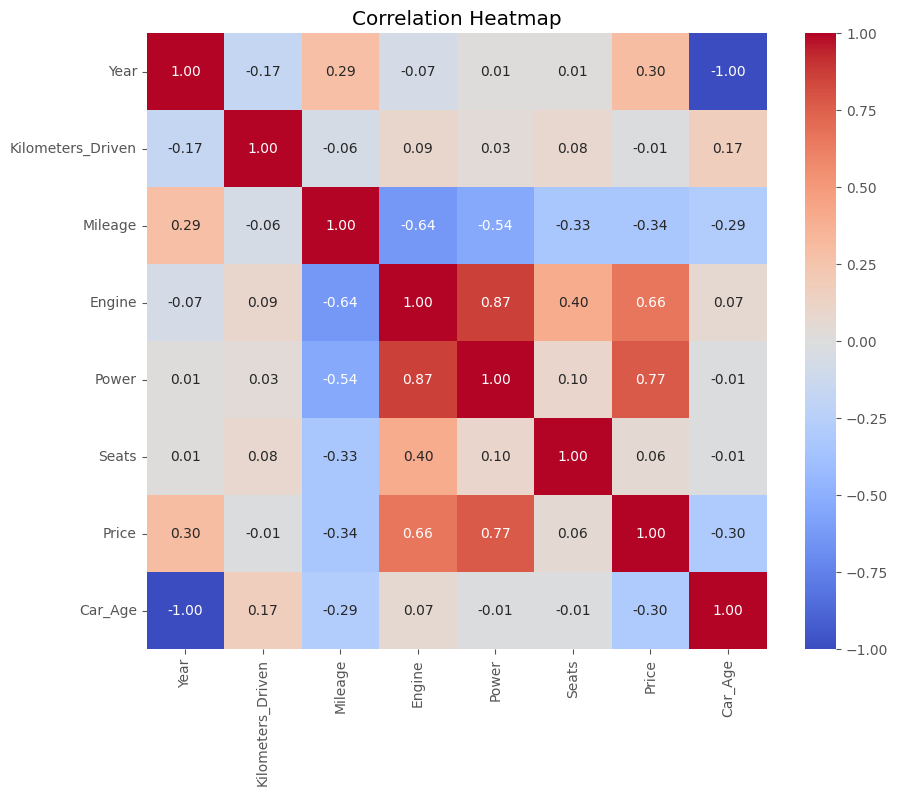

In [ ]:
# ==========================
# Cell 10: Correlation Analysis
# ==========================

# Correlation for numerical columns
plt.figure(figsize=(10,8))

numeric_df = car_df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# ==========================
# Cell 11: Encode Categorical Features
# ==========================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type",
    "Brand"
]

label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    car_df[column] = le.fit_transform(car_df[column])
    label_encoders[column] = le

print("✅ Categorical Features Encoded Successfully")

display(car_df.head())

✅ Categorical Features Encoded Successfully


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,9,2010,72000,0,1,0,26.60,998,58.16,5.0,1.75,18,16
1,10,2015,41000,1,1,0,19.67,1582,126.20,5.0,12.50,10,11
2,2,2011,46000,3,1,0,18.20,1199,88.70,5.0,4.50,9,15
3,2,2012,87000,1,1,0,20.77,1248,88.76,7.0,6.00,18,14
4,3,2013,40670,1,0,2,15.20,1968,140.80,5.0,17.74,1,13


In [ ]:
# ==========================
# Cell 12: Verify Encoded Dataset
# ==========================

print("Dataset Shape:", car_df.shape)

print("\nData Types:")
print(car_df.dtypes)

print("\nMissing Values:")
print(car_df.isnull().sum())

display(car_df.head())

Dataset Shape: (5872, 13)

Data Types:
Location               int64
Year                   int64
Kilometers_Driven      int64
Fuel_Type              int64
Transmission           int64
Owner_Type             int64
Mileage              float64
Engine                 int64
Power                float64
Seats                float64
Price                float64
Brand                  int64
Car_Age                int64
dtype: object

Missing Values:
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
Brand                0
Car_Age              0
dtype: int64


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,9,2010,72000,0,1,0,26.60,998,58.16,5.0,1.75,18,16
1,10,2015,41000,1,1,0,19.67,1582,126.20,5.0,12.50,10,11
2,2,2011,46000,3,1,0,18.20,1199,88.70,5.0,4.50,9,15
3,2,2012,87000,1,1,0,20.77,1248,88.76,7.0,6.00,18,14
4,3,2013,40670,1,0,2,15.20,1968,140.80,5.0,17.74,1,13


In [ ]:
# ==========================
# Cell 13: Define Features and Target
# ==========================

X = car_df.drop(columns=["Price"])

y = car_df["Price"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape : (5872, 12)
Target Vector Shape : (5872,)


In [ ]:
# ==========================
# Cell 14: Train-Test Split
# ==========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (4697, 12)
Testing Samples : (1175, 12)


In [ ]:
# ==========================
# Cell 15: Train Baseline Random Forest Model
# ==========================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

baseline_pred = rf_model.predict(X_test)

print("="*50)
print("Baseline Random Forest Performance")
print("="*50)

print("R² Score :", round(r2_score(y_test, baseline_pred),4))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, baseline_pred)),4))
print("MAE :", round(mean_absolute_error(y_test, baseline_pred),4))

Baseline Random Forest Performance
R² Score : 0.8752
RMSE : 3.6188
MAE : 1.4867


In [ ]:
# ==========================
# Cell 16: Save Model and Encoders
# ==========================

import pickle

# Save trained model
with open("car_price_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

# Save label encoders
with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

print("✅ Model saved as car_price_model.pkl")
print("✅ Label Encoders saved as label_encoders.pkl")

✅ Model saved as car_price_model.pkl
✅ Label Encoders saved as label_encoders.pkl


In [ ]:
# ==========================
# Cell 17: Test Saved Model
# ==========================

with open("car_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

prediction = loaded_model.predict(X_test.iloc[:5])

result = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": prediction
})

display(result)

,Actual Price,Predicted Price
0,31.00,16.713800
1,12.50,10.927250
2,19.90,23.262900
3,8.92,9.209075
4,24.68,17.605300


In [ ]:
# ==========================
# Cell 18: Download Model Files
# ==========================

from google.colab import files

files.download("car_price_model.pkl")
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(len(label_encoders["Brand"].classes_))
print(label_encoders["Brand"].classes_[:20])

30
['Ambassador' 'Audi' 'BMW' 'Bentley' 'Chevrolet' 'Datsun' 'Fiat' 'Force'
 'Ford' 'Honda' 'Hyundai' 'ISUZU' 'Isuzu' 'Jaguar' 'Jeep' 'Lamborghini'
 'Land' 'Mahindra' 'Maruti' 'Mercedes-Benz']
